In [ ]:
''' A weather monitoring system to predict tomorrow's tempreature using past temperature values. This is time series forecasting problem where the output depends on
previous observation'''
#step1: import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
#step2: Creating time series data
def create_dataset(data, time_steps=5):
  X,y=[],[]
  for i in range(len(data)-time_steps):
    X.append(data[i:(i+time_steps)])
    y.append(data[i+time_steps])
  return np.array(X), np.array(y)
#sample temperature data
temperatures=np.array([30,31,32,33,34,35,36,37,38,39])
X,y=create_dataset(temperatures,time_steps=3)
#reshape for RNN:(samples,time series,features)
X=X.reshape((X.shape[0],X.shape[1],1))


In [ ]:
#step3 build RNN model
model=Sequential([
    SimpleRNN(20,activation='tanh',input_shape=(3,1)),
    Dense(1)
    ])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_10 (SimpleRNN)       │ (None, 20)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#step4: train model
model.fit(X,y,epochs=200,verbose=0)

In [ ]:
#step5: predict tomorrow's temperature
last_days=np.array([[37,38,39]])
last_days=last_days.reshape((1,3,1))
prediction=model.predict(last_days)
print("Predicted temperature",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Predicted temperature 4.450636


In [ ]:
import matplotlib.pyplot as plt

split = int(len(X) * 0.8)  # 80% train, 20% test
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model.fit(X_train, y_train, epochs=200, verbose=0)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


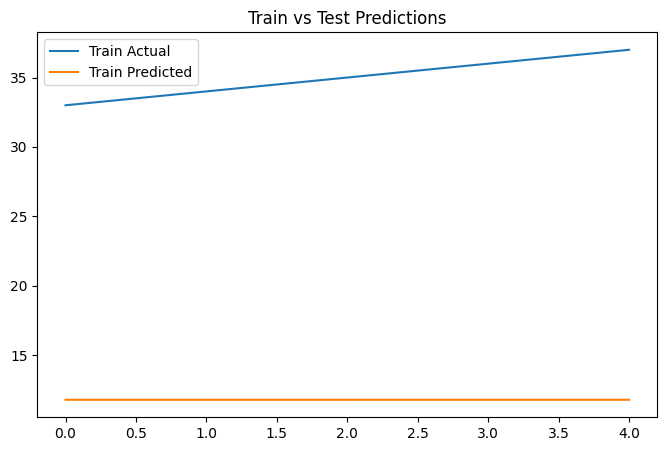

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

plt.figure(figsize=(8,5))
plt.plot(y_train, label="Train Actual")
plt.plot(y_train_pred, label="Train Predicted")
plt.legend()
plt.title("Train vs Test Predictions")
plt.show()


In [ ]:
loss=model.evaluate(X_test,y_test)
print("Test Loss (MSE):",loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 714.4238
Test Loss (MSE): 714.423828125
